In [ ]:
!pip -q install transformers torch torchvision pillow matplotlib

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from google.colab import files
from transformers import SamModel, SamProcessor

In [ ]:
if torch.cuda.is_available():
    print("GPU is available")
    print("GPU name:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT available (CPU mode)")

GPU is available
GPU name: Tesla T4


Saving laptop.jpeg to laptop.jpeg
image size: (960, 720)


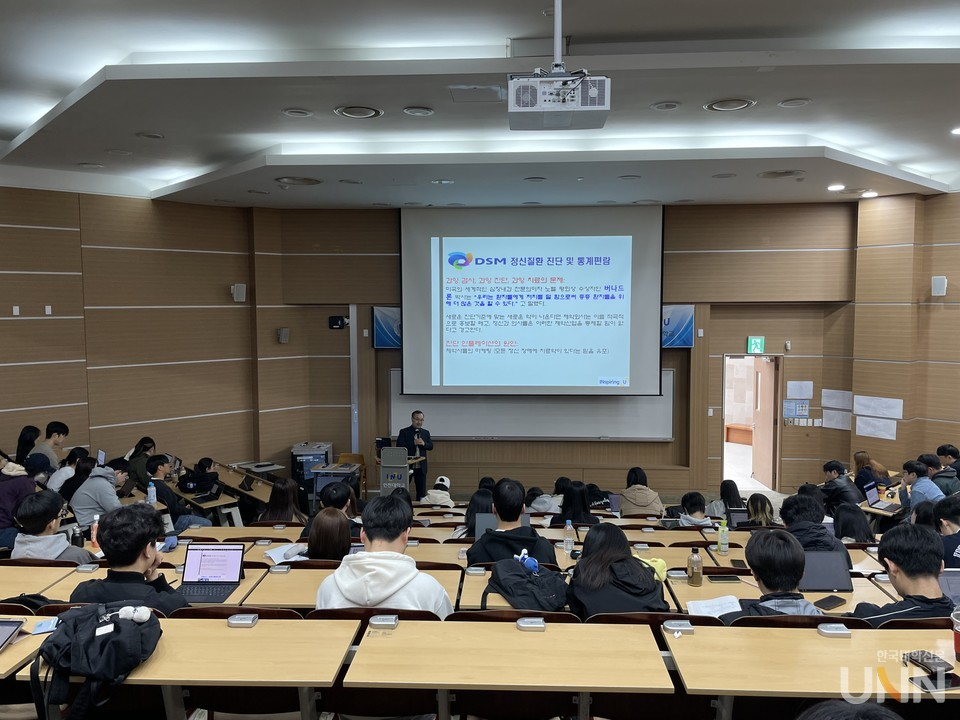

In [ ]:
uploaded = files.upload()

image_path = list(uploaded.keys())[0]
image = Image.open(image_path).convert("RGB")

print("image size:", image.size)
image

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
model_name = "facebook/sam-vit-base"

processor = SamProcessor.from_pretrained(model_name)
model = SamModel.from_pretrained(model_name).to(device)

print("SAM loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

The image processor of type `SamImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/375M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/314 [00:00<?, ?it/s]

SAM loaded.


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51340 (\N{HANGUL SYLLABLE JWA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54364 (\N{HANGUL SYLLABLE PYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47484 (\N{HANGUL SYLLABLE REUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48372 (\N{HANGUL SYLLABLE BO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

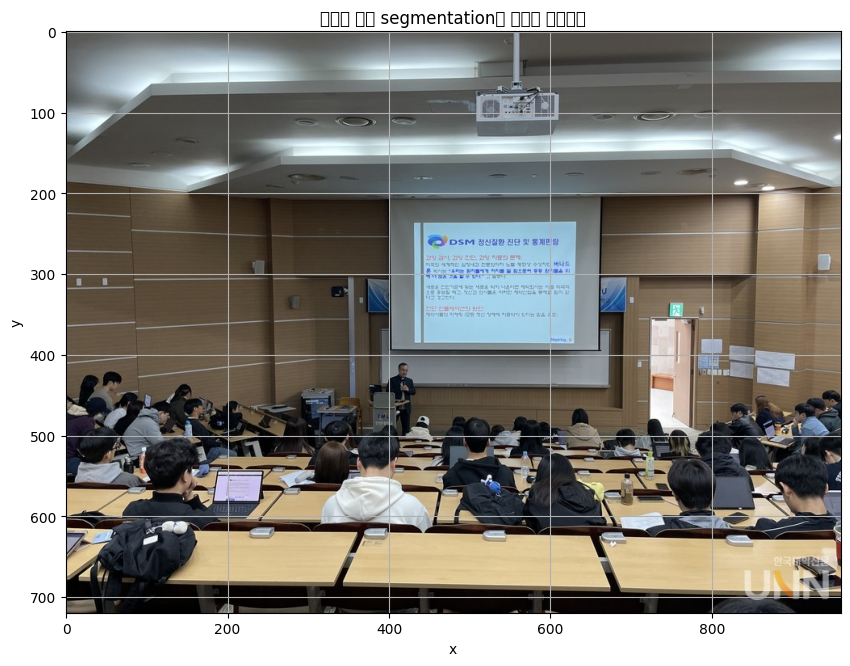

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.imshow(image)
ax.set_title("좌표를 보고 segmentation할 위치를 정하세요")
ax.grid(True)
ax.set_xlabel("x")
ax.set_ylabel("y")
plt.show()

In [ ]:
input_points = [[[200, 550]]]
input_labels = [[[1]]]

In [ ]:
inputs = processor(
    images=image,
    input_points=input_points,
    input_labels=input_labels,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(),
    inputs["original_sizes"].cpu(),
    inputs["reshaped_input_sizes"].cpu()
)

scores = outputs.iou_scores.cpu()

In [ ]:
all_masks = masks[0][0]
all_scores = scores[0][0]

best_idx = all_scores.argmax().item()

mask = all_masks[best_idx].numpy()
score = all_scores[best_idx].item()

print("Best score:", score)

Best score: 0.9716397523880005


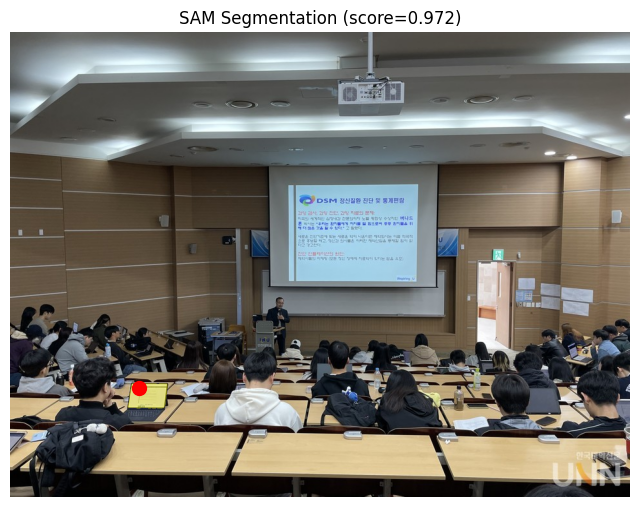

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(image)

mask_bool = mask > 0

overlay = np.zeros((mask.shape[0], mask.shape[1], 4))
overlay[..., 0] = 1.0
overlay[..., 1] = 1.0
overlay[..., 2] = 0.0
overlay[..., 3] = mask_bool * 0.45

plt.imshow(overlay)

for p in input_points[0]:
    plt.scatter(p[0], p[1], c='red', s=100)

plt.title(f"SAM Segmentation (score={score:.3f})")
plt.axis("off")
plt.show()